In [1]:
!pip install datasets pycddlib umap-learn dask dask-expr cvxopt seaborn plotly --break-system-packages

  Using cached datasets-4.8.4-py3-none-any.whl.metadata (19 kB)
  Using cached pycddlib-3.0.2.tar.gz (31 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached umap_learn-0.5.11-py3-none-any.whl.metadata (26 kB)
  Using cached dask-2026.3.0-py3-none-any.whl.metadata (3.9 kB)
  Using cached dask_expr-2.0.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached cvxopt-1.3.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (43 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached plotly-6.6.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached numpy-2.4.4-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pyarrow-23.0.1-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (3.1 kB)
  Using cached dill-0.4.1-py3-none-any.whl.metadata (10 kB)
  Using c

In [38]:
import os
from datasets import load_dataset
from datasets import Dataset
from collections import Counter, defaultdict
from tqdm.auto import tqdm

import pandas as pd
pd.set_option("display.max_rows", None)

import random
import numpy as np

from numba import jit

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import classification_report

from scipy.spatial import ConvexHull

import polytope as pc

import cdd

from umap import UMAP

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

Dataset hat 473800776 Zeilen und die Spalten: 'vertices', 'vertex_count', 'facet_count', 'point_count', 'dual_point_count', 'h11', 'h12', 'euler_characteristic'.

In [5]:
# Do this only once!
dataset = load_dataset(
    "calabi-yau-data/polytopes-4d",
    split="full",
    cache_dir="/home/jovyan/.cache/huggingface"
)
print(dataset)

Generating full split: 100%|██████████| 473800776/473800776 [04:08<00:00, 1906080.08 examples/s]


Dataset({
    features: ['vertices', 'vertex_count', 'facet_count', 'point_count', 'dual_point_count', 'h11', 'h12', 'euler_characteristic'],
    num_rows: 473800776
})


In [9]:
# After downloading data work in offline mode!
os.environ["HF_DATASETS_OFFLINE"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"

vertex_count_data = load_dataset(
    "calabi-yau-data/polytopes-4d",
    split="full",
    cache_dir="/home/jovyan/.cache/huggingface"
).select_columns(["vertex_count"])

print(vertex_count_data)


Dataset({
    features: ['vertex_count'],
    num_rows: 473800776
})


In [10]:
batch_size = 100_000
vertex_counts = pd.Series(dtype="int64")

rows = len(vertex_count_data)
print(f"Total rows: {rows:,}")

for start in range(0, rows, batch_size):
    end = min(start + batch_size, rows)
    batch = vertex_count_data.select(
        range(start, end)
    ).to_pandas()

    vertex_counts = vertex_counts.add(
        batch["vertex_count"].value_counts(),
        fill_value=0
    )

vertex_counts = vertex_counts.astype("int64").sort_index()

Total rows: 473,800,776


In [13]:
vertex_counts_4d_df = (vertex_counts.rename_axis("vertex_count").reset_index(name="count"))
print(vertex_counts_4d_df)

    vertex_count     count
0              5      1561
1              6     24189
2              7    177446
3              8    834638
4              9   2867955
5             10   7725801
6             11  16608387
7             12  29270253
8             13  43458000
9             14  56060584
10            15  64085869
11            16  65615931
12            17  59972682
13            18  48703033
14            19  34847821
15            20  21913680
16            21  12070919
17            22   5826221
18            23   2450720
19            24    898929
20            25    284696
21            26     78468
22            27     18417
23            28      3781
24            29       647
25            30       114
26            31        23
27            32         8
28            33         2
29            36         1


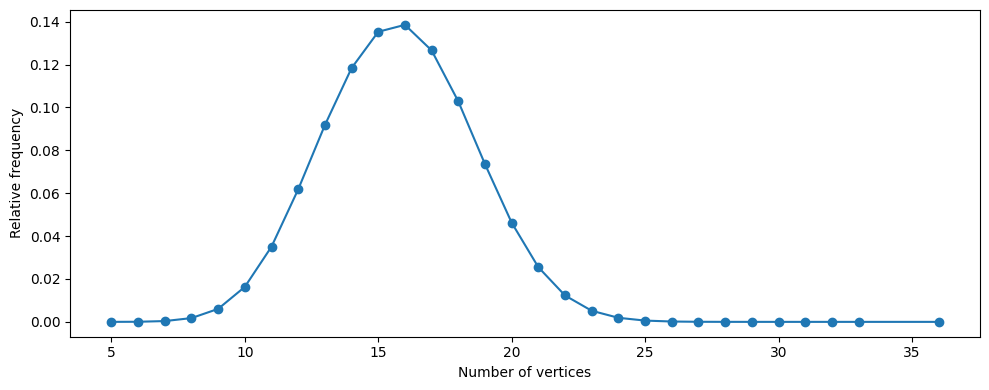

In [23]:
vertex_counts_4d_df["relative_frequency"] = (
    vertex_counts_4d_df["count"] /
    vertex_counts_4d_df["count"].sum()
)

plt.figure(figsize=(10, 4))

plt.plot(
    vertex_counts_4d_df["vertex_count"],
    vertex_counts_4d_df["relative_frequency"],
    marker="o",
    linestyle="-"
)

plt.xlabel("Number of vertices")
plt.ylabel("Relative frequency")


plt.tight_layout()
plt.savefig("poly4d-normalized-vertex-dist.png", dpi=300, bbox_inches="tight")
plt.show()

# Analyze simple symmetries

In [16]:
symmetry_data = load_dataset(
    "calabi-yau-data/polytopes-4d",
    split="full",
    cache_dir="/home/jovyan/.cache/huggingface"
).select_columns([
    "vertex_count",
    "point_count",
    "dual_point_count"
])
symmetry_data

Dataset({
    features: ['vertex_count', 'point_count', 'dual_point_count'],
    num_rows: 473800776
})

In [33]:
BATCH_SIZE = 100_000
MAX_PER_VERTEX = 3_000
rng = 42

samples = defaultdict(list)
rows = len(symmetry_data)

for start in range(0, rows, BATCH_SIZE):
    end = min(start + BATCH_SIZE, rows)
    batch = symmetry_data.select(range(start, end)).to_pandas()
    batch["dataset_index"] = range(start, end)
    
    for vc, sub in batch.groupby("vertex_count"):
        remaining = MAX_PER_VERTEX - len(samples[vc])
        if remaining <= 0:
            continue

        take = sub.sample(
            n=min(len(sub), remaining),
            random_state=rng
        )

        samples[vc].append(take)

# Zusammenbauen
sampled_data = pd.concat(
    [pd.concat(v, ignore_index=True) for v in samples.values()],
    ignore_index=True
)

sampled_data.head(), len(sampled_data)

(   vertex_count  point_count  dual_point_count  dataset_index
 0             5           45                97           1526
 1             5          281                31           1026
 2             5           17                65            354
 3             5           37                25            669
 4             5           17                27            643,
 13152929)

## Vertex to point ratio distribution

In [35]:
sampled_data["vertex_to_point_ratio"] = (
    sampled_data["vertex_count"] / sampled_data["point_count"]
)

sampled_data["vertex_to_dual_point_ratio"] = (
    sampled_data["vertex_count"] / sampled_data["dual_point_count"]
)

sampled_data["vertex_count"].value_counts().sort_index()

vertex_count
5        1561
6        3000
7        8997
8       26964
9       89565
10     230997
11     487139
12     838929
13    1210605
14    1528359
15    1720239
16    1755504
17    1622700
18    1345172
19     986274
20     635910
21     358619
22     175289
23      77675
24      29955
25       8997
26       3684
27       3000
28       3000
29        647
30        114
31         23
32          8
33          2
36          1
Name: count, dtype: int64

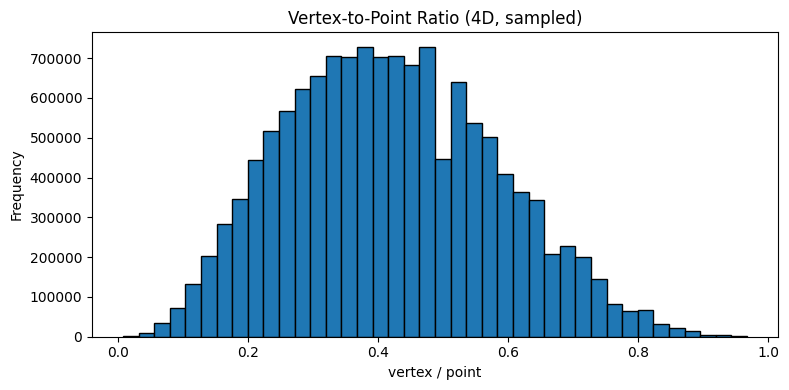

In [19]:
plt.figure(figsize=(8, 4))
plt.hist(
    sampled_data["vertex_to_point_ratio"],
    bins=40,
    edgecolor="black"
)

plt.xlabel("vertex / point")
plt.ylabel("Frequency")
plt.title("Vertex-to-Point Ratio (4D, sampled)")
plt.tight_layout()
plt.show()

<module 'matplotlib.pyplot' from '/opt/conda/lib/python3.11/site-packages/matplotlib/pyplot.py'>

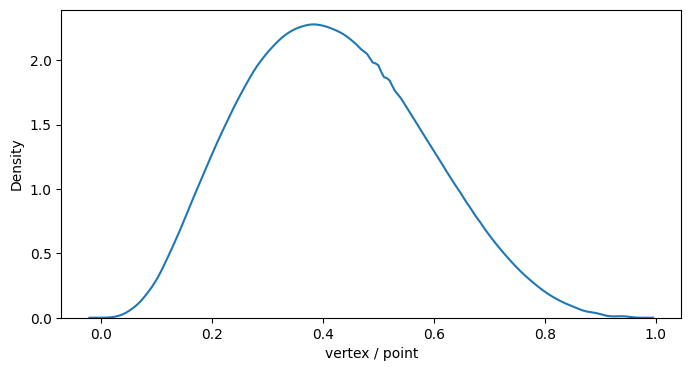

In [20]:
plt.figure(figsize=(8, 4))

sns.kdeplot(
    sampled_data["vertex_to_point_ratio"],
    bw_adjust=1.5,
    fill=False
)

plt.xlabel("vertex / point")
plt

## Plot vertex to point ratio distributions by vertex count

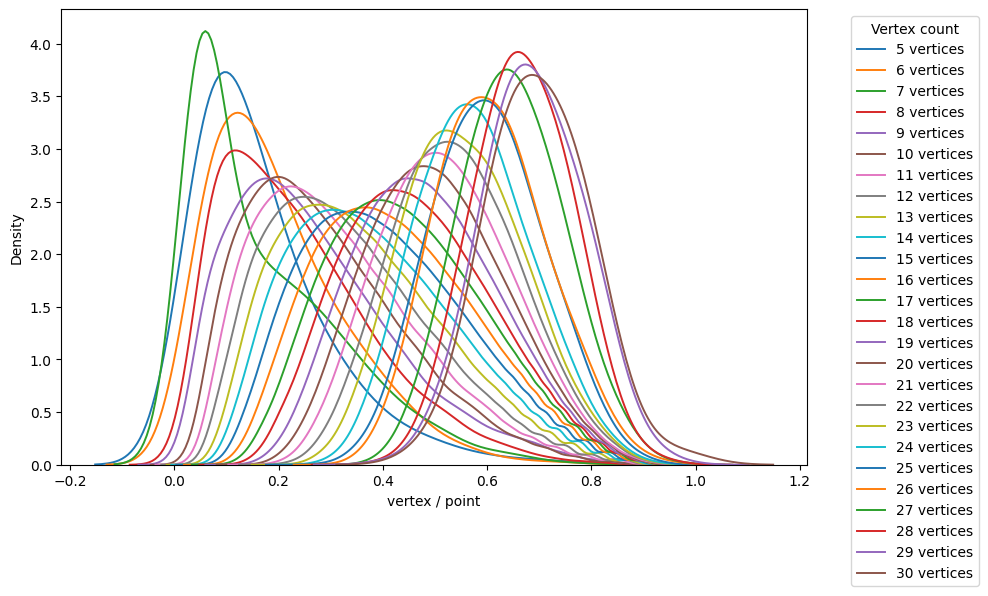

In [26]:
plt.figure(figsize=(10, 6))

for vc in sorted(sampled_data["vertex_count"].unique()):
    subset = sampled_data[sampled_data["vertex_count"] == vc]
    if len(subset) < 100:
        continue

    sns.kdeplot(
        subset["vertex_to_point_ratio"],
        label=f"{vc} vertices",
        bw_adjust=1.8,
        linewidth=1.4
    )

plt.xlabel("vertex / point")
plt.ylabel("Density")
plt.legend(
    title="Vertex count",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.savefig("poly4d-vertex-point-ratio-by-vertexcount.png", dpi=300, bbox_inches="tight")
plt.show()

## Plot vertex to dual point ratio distributions by vertex count

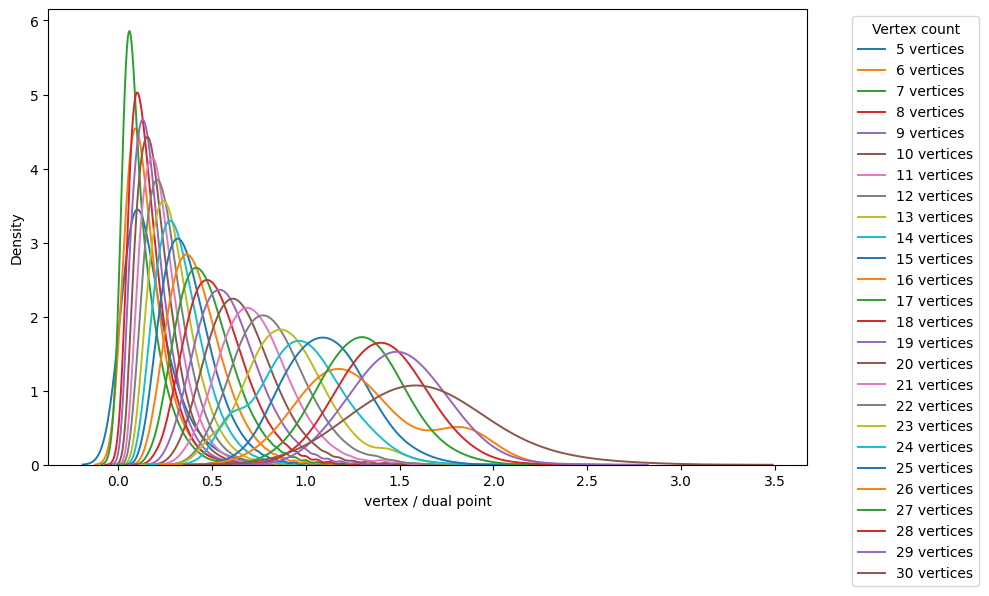

In [27]:
plt.figure(figsize=(10, 6))

for vc in sorted(sampled_data["vertex_count"].unique()):
    subset = sampled_data[sampled_data["vertex_count"] == vc]
    if len(subset) < 100:
        continue

    sns.kdeplot(
        subset["vertex_to_dual_point_ratio"],
        label=f"{vc} vertices",
        bw_adjust=2.2,
        linewidth=1.4
    )

plt.xlabel("vertex / dual point")
plt.ylabel("Density")
plt.legend(
    title="Vertex count",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.savefig("poly4d-vertex-dualpoint-ratio-by-vertexcount.png", dpi=300, bbox_inches="tight")
plt.show()

## 3D Visualization of a 4D Polytope (UMAP Projection and Convex Hull)

/opt/conda/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/conda/lib/python3.11/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


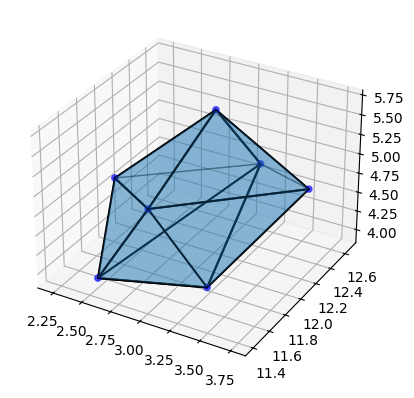

In [37]:
sampled_data["is_outlier"] = sampled_data.groupby("vertex_count")[
    "vertex_to_point_ratio"
].transform(
    lambda x: x > x.quantile(0.99)
)

threshold = sampled_data["vertex_to_point_ratio"].quantile(0.995)
sampled_data["is_outlier"] = sampled_data["vertex_to_point_ratio"] > threshold

outliers = sampled_data[sampled_data["is_outlier"]]
first_outlier = outliers.iloc[0]

# Load Vertices
idx = int(first_outlier["dataset_index"])

full_data = load_dataset(
    "calabi-yau-data/polytopes-4d",
    split="full",
    cache_dir="/home/jovyan/.cache/huggingface"
)

poly = full_data[idx]
vertices_4d = np.vstack(poly["vertices"])

# --- Dimensionality reduction: 4D -> 3D ---
# Alternative: PCA
# pca = PCA(n_components=3)
# vertices_3d = pca.fit_transform(vertices_4d)
umap = UMAP(n_components=3, random_state=42)
vertices_3d = umap.fit_transform(vertices_4d)

# --- Convex hull in embedded 3D space ---
hull = ConvexHull(vertices_3d)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(vertices_3d[:, 0], vertices_3d[:, 1], vertices_3d[:, 2], color='blue', alpha=0.6)

for simplex in hull.simplices:
    points = vertices_3d[simplex]
    ax.plot(points[:, 0], points[:, 1], points[:, 2], 'k-')

faces = Poly3DCollection(vertices_3d[hull.simplices], alpha=0.3, edgecolor='k')
ax.add_collection3d(faces)

plt.show()

# New Experiments

In [41]:
# =========================
# PARAMETERS
# =========================
batch_size = 100_000

# Falls dein HuggingFace-Dataset anders heißt, hier anpassen:
# z.B. ds4d oder dataset["train"]
ds = dataset

rows = len(ds)
print(f"Total rows: {rows:,}")

# =========================
# ACCUMULATORS
# =========================
# Global counts in (s,d)
counts_sd = Counter()

# Conditional counts for each vertex_count v:
# counts_vsd[v] is a Counter over (s,d)
counts_vsd = defaultdict(Counter)

# Optional: marginal count per vertex_count
counts_v = Counter()

# =========================
# MAIN LOOP
# =========================
for start in tqdm(range(0, rows, batch_size), desc="Processing batches"):
    end = min(start + batch_size, rows)

    batch = ds.select(range(start, end)).to_pandas()

    # Keep only needed columns
    batch = batch[["vertex_count", "h11", "h12"]].copy()

    # Derived coordinates
    batch["s"] = batch["h11"] + batch["h12"]
    batch["d"] = batch["h11"] - batch["h12"]

    # ---------
    # Global (s,d) counts
    # ---------
    sd_counts_batch = batch.groupby(["s", "d"]).size()
    for (s, d), c in sd_counts_batch.items():
        counts_sd[(int(s), int(d))] += int(c)

    # ---------
    # Conditional counts by vertex_count
    # ---------
    vsd_counts_batch = batch.groupby(["vertex_count", "s", "d"]).size()
    for (v, s, d), c in vsd_counts_batch.items():
        counts_vsd[int(v)][(int(s), int(d))] += int(c)
        counts_v[int(v)] += int(c)

print("Done.")
print(f"Unique (s,d) states globally: {len(counts_sd):,}")
print(f"Number of vertex_count slices: {len(counts_vsd):,}")

# =========================
# CONVERT TO DATAFRAMES
# =========================
df_sd = pd.DataFrame(
    [(s, d, c, np.log(c)) for (s, d), c in counts_sd.items()],
    columns=["s", "d", "count", "log_count"]
).sort_values(["s", "d"]).reset_index(drop=True)

df_vsd_rows = []
for v, counter in counts_vsd.items():
    for (s, d), c in counter.items():
        df_vsd_rows.append((v, s, d, c, np.log(c)))

df_vsd = pd.DataFrame(
    df_vsd_rows,
    columns=["vertex_count", "s", "d", "count", "log_count"]
).sort_values(["vertex_count", "s", "d"]).reset_index(drop=True)

df_v = pd.DataFrame(
    [(v, c) for v, c in counts_v.items()],
    columns=["vertex_count", "count"]
).sort_values("vertex_count").reset_index(drop=True)

print("\nGlobal (s,d) table:")
display(df_sd.head())

print("\nConditional (v,s,d) table:")
display(df_vsd.head())

print("\nVertex-count totals:")
display(df_v.head())

# =========================
# SAVE RESULTS
# =========================
df_sd.to_parquet("counts_sd_4d_reflexive.parquet", index=False)
df_vsd.to_parquet("counts_vsd_4d_reflexive.parquet", index=False)
df_v.to_parquet("counts_v_4d_reflexive.parquet", index=False)

print("\nSaved:")
print("- counts_sd_4d_reflexive.parquet")
print("- counts_vsd_4d_reflexive.parquet")
print("- counts_v_4d_reflexive.parquet")

Total rows: 473,800,776


Processing batches: 100%|██████████| 4739/4739 [22:23<00:00,  3.53it/s]


Done.
Unique (s,d) states globally: 30,108
Number of vertex_count slices: 30

Global (s,d) table:


,s,d,count,log_count
0,22,-20,1,0.0
1,22,20,1,0.0
2,25,-15,1,0.0
3,25,15,1,0.0
4,26,-12,1,0.0



Conditional (v,s,d) table:


,vertex_count,s,d,count,log_count
0,5,22,-20,1,0.0
1,5,22,20,1,0.0
2,5,30,-12,1,0.0
3,5,30,12,1,0.0
4,5,32,-6,1,0.0



Vertex-count totals:


,vertex_count,count
0,5,1561
1,6,24189
2,7,177446
3,8,834638
4,9,2867955



Saved:
- counts_sd_4d_reflexive.parquet
- counts_vsd_4d_reflexive.parquet
- counts_v_4d_reflexive.parquet


In [42]:
df_sd.shape, df_vsd.shape, df_v.shape
df_sd.sort_values("count", ascending=False).head(20)

,s,d,count,log_count
815,54,0,910113,13.721324
636,50,0,877191,13.684480
722,52,0,875275,13.682293
816,54,2,861439,13.666360
814,54,-2,861439,13.666360
910,56,0,856560,13.660680
723,52,2,841741,13.643228
721,52,-2,841741,13.643228
1008,58,0,841586,13.643043
720,52,-4,838090,13.638881


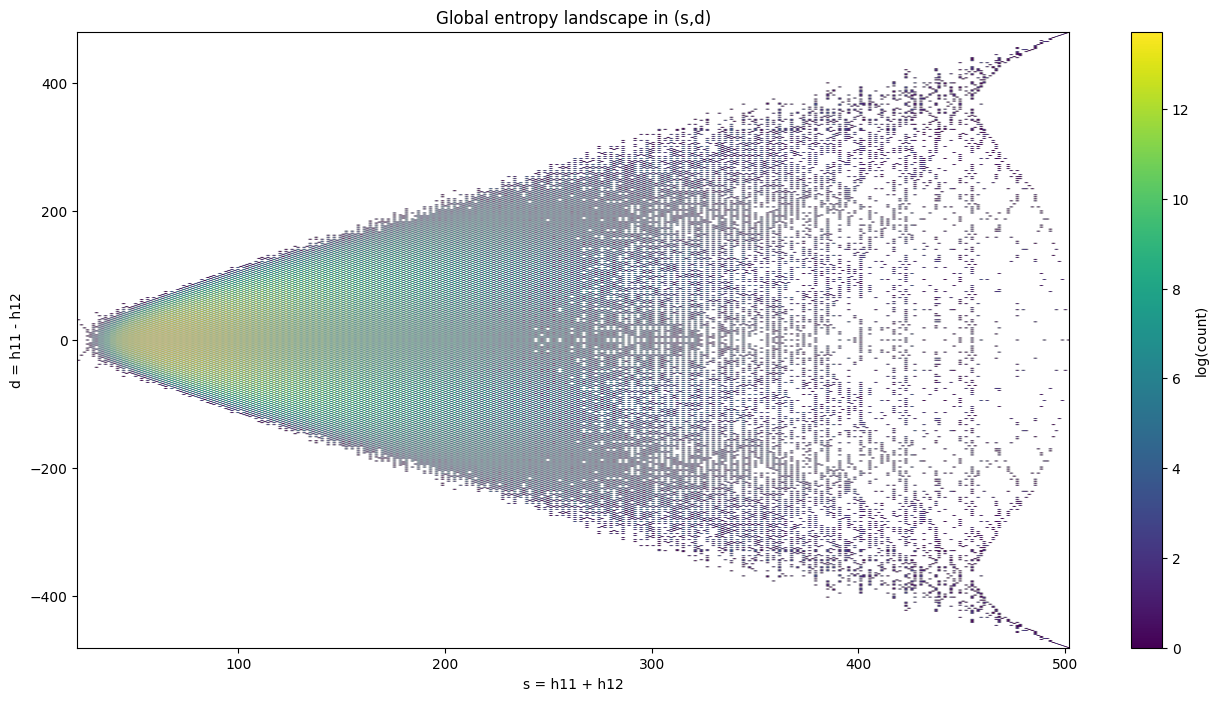

Ridge table:


,s,d_peak,count_peak,log_count_peak
0,22,-20,1,0.000000
1,25,-15,1,0.000000
2,26,-12,1,0.000000
3,28,0,3,1.098612
4,29,-3,3,1.098612
5,30,0,99,4.595120
6,31,-3,22,3.091042
7,32,0,768,6.643790
8,33,-3,553,6.315358
9,34,0,6258,8.741616


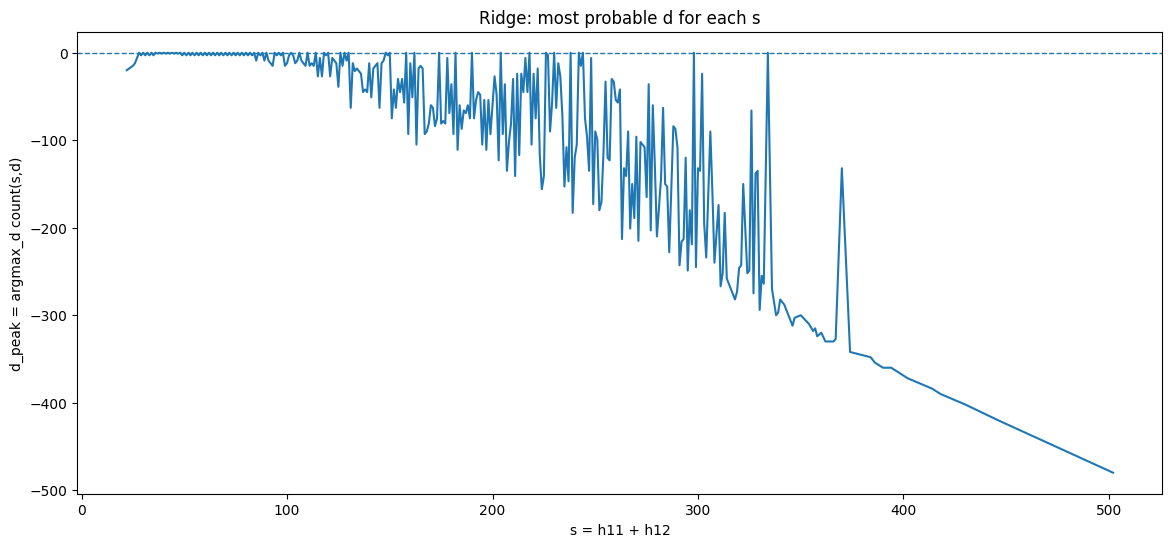

Width table:


,s,total_count,d_mean,d_std,d_mode,count_mode,support_size
0,22,2.0,0.0,20.000000,-20.0,1.0,2.0
1,25,2.0,0.0,15.000000,-15.0,1.0,2.0
2,26,2.0,0.0,12.000000,-12.0,1.0,2.0
3,28,11.0,0.0,6.660603,0.0,3.0,7.0
4,29,12.0,0.0,5.000000,-3.0,3.0,6.0
5,30,345.0,0.0,5.154989,0.0,99.0,17.0
6,31,82.0,0.0,6.958063,-3.0,22.0,12.0
7,32,4152.0,0.0,5.469129,0.0,768.0,23.0
8,33,2710.0,0.0,5.581400,-3.0,553.0,20.0
9,34,37864.0,0.0,5.616447,0.0,6258.0,25.0


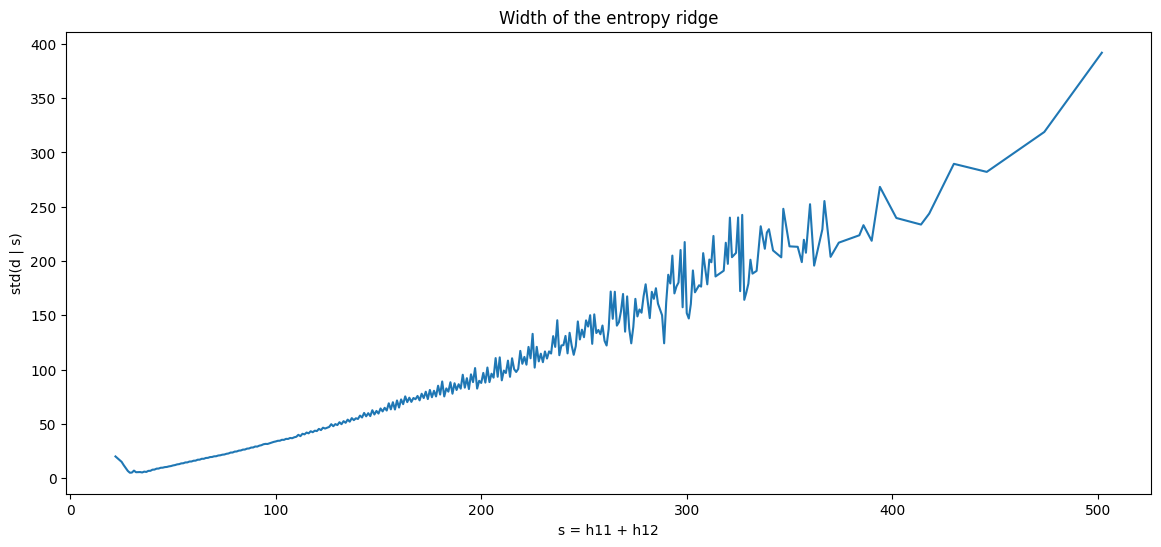

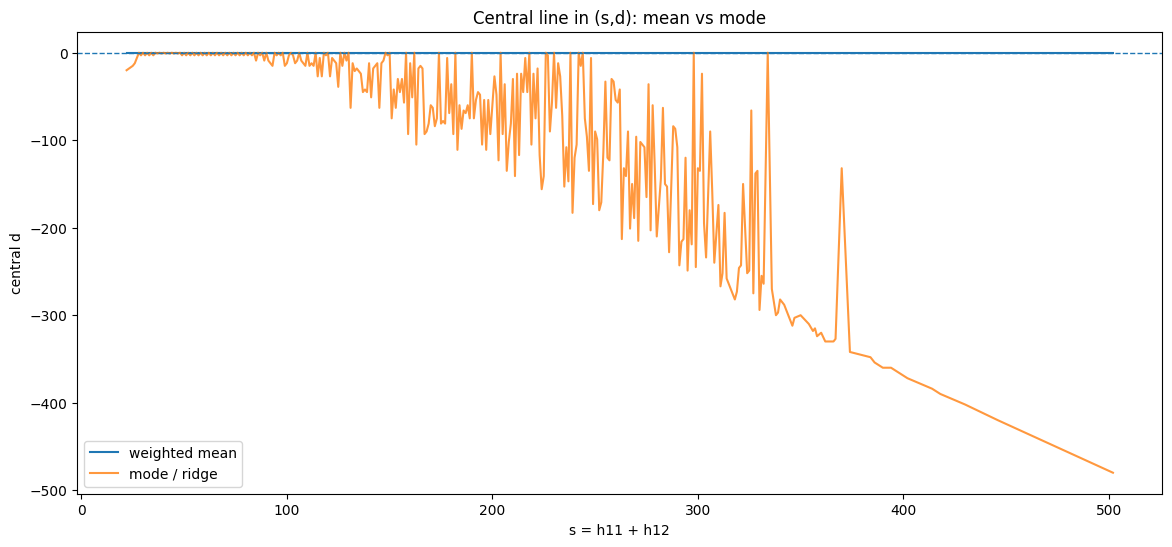

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) GLOBAL HEATMAP MATRIX
# =========================
pivot_sd = df_sd.pivot(index="d", columns="s", values="log_count").sort_index()

plt.figure(figsize=(16, 8))
plt.imshow(
    pivot_sd,
    aspect="auto",
    origin="lower",
    extent=[
        pivot_sd.columns.min(), pivot_sd.columns.max(),
        pivot_sd.index.min(), pivot_sd.index.max()
    ]
)
plt.colorbar(label="log(count)")
plt.xlabel("s = h11 + h12")
plt.ylabel("d = h11 - h12")
plt.title("Global entropy landscape in (s,d)")
plt.show()

# =========================
# 2) RIDGE EXTRACTION
# For each s, pick d with maximal count
# =========================
ridge_idx = df_sd.groupby("s")["count"].idxmax()
df_ridge = df_sd.loc[ridge_idx].sort_values("s").reset_index(drop=True)
df_ridge = df_ridge.rename(columns={"d": "d_peak", "count": "count_peak", "log_count": "log_count_peak"})

print("Ridge table:")
display(df_ridge.head(20))

plt.figure(figsize=(14, 6))
plt.plot(df_ridge["s"], df_ridge["d_peak"])
plt.axhline(0, linewidth=1, linestyle="--")
plt.xlabel("s = h11 + h12")
plt.ylabel("d_peak = argmax_d count(s,d)")
plt.title("Ridge: most probable d for each s")
plt.show()

# =========================
# 3) WIDTH AROUND RIDGE
# For each s, compute weighted mean and std in d
# =========================
def weighted_stats(group):
    d = group["d"].to_numpy(dtype=float)
    w = group["count"].to_numpy(dtype=float)

    wsum = w.sum()
    mean = (w * d).sum() / wsum
    var = (w * (d - mean)**2).sum() / wsum
    std = np.sqrt(var)

    # modal value
    i = np.argmax(w)
    d_mode = d[i]
    count_mode = w[i]

    return pd.Series({
        "total_count": wsum,
        "d_mean": mean,
        "d_std": std,
        "d_mode": d_mode,
        "count_mode": count_mode,
        "support_size": len(group)
    })

df_width = df_sd.groupby("s").apply(weighted_stats).reset_index()

print("Width table:")
display(df_width.head(20))

plt.figure(figsize=(14, 6))
plt.plot(df_width["s"], df_width["d_std"])
plt.xlabel("s = h11 + h12")
plt.ylabel("std(d | s)")
plt.title("Width of the entropy ridge")
plt.show()

# =========================
# 4) Compare mode and weighted mean
# =========================
plt.figure(figsize=(14, 6))
plt.plot(df_width["s"], df_width["d_mean"], label="weighted mean")
plt.plot(df_ridge["s"], df_ridge["d_peak"], label="mode / ridge", alpha=0.8)
plt.axhline(0, linewidth=1, linestyle="--")
plt.xlabel("s = h11 + h12")
plt.ylabel("central d")
plt.title("Central line in (s,d): mean vs mode")
plt.legend()
plt.show()

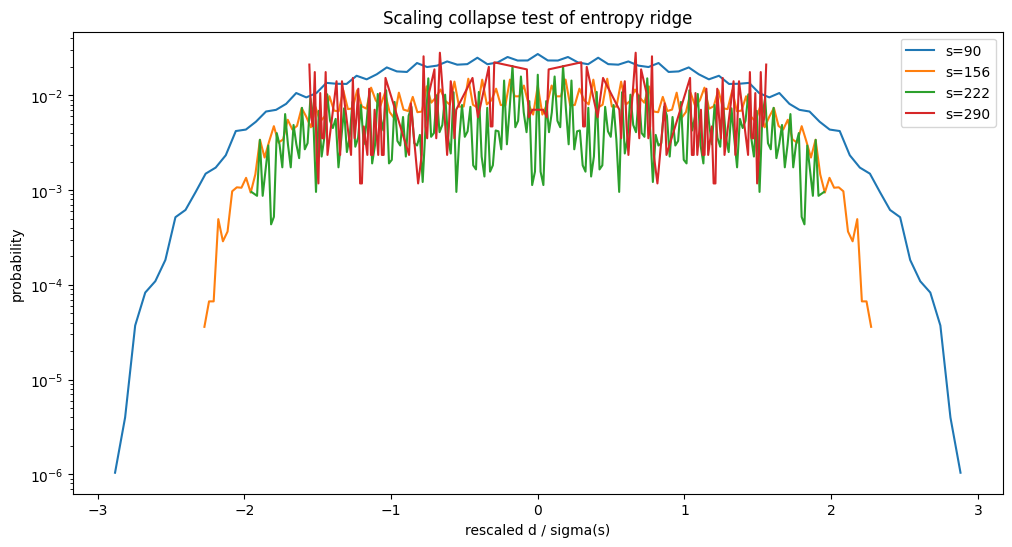

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# BUILD RESCALED DISTRIBUTIONS
# =========================

selected_s = df_width["s"].quantile([0.2, 0.4, 0.6, 0.8]).astype(int).values

plt.figure(figsize=(12, 6))

for s_val in selected_s:
    group = df_sd[df_sd["s"] == s_val]

    d = group["d"].to_numpy()
    w = group["count"].to_numpy()

    # normalize weights
    w = w / w.sum()

    # rescale
    std = df_width.loc[df_width["s"] == s_val, "d_std"].values[0]
    x = d / std

    # sort for plotting
    idx = np.argsort(x)
    x = x[idx]
    w = w[idx]

    plt.plot(x, w, label=f"s={s_val}")

plt.xlabel("rescaled d / sigma(s)")
plt.ylabel("probability")
plt.title("Scaling collapse test of entropy ridge")
plt.legend()
plt.yscale("log")
plt.show()

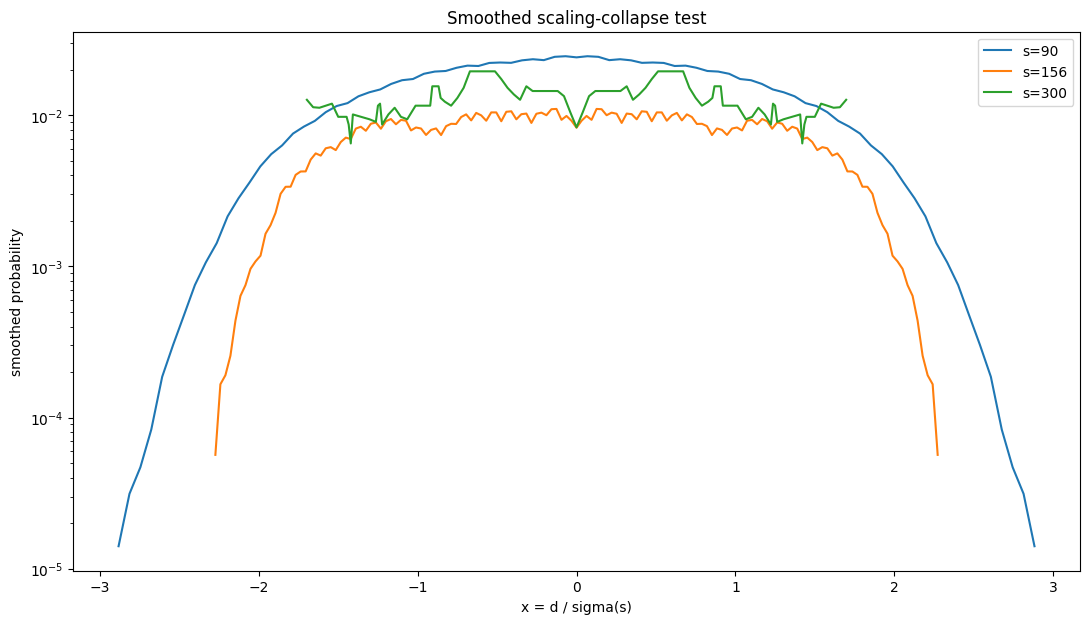

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Pick a few representative s values
# =========================
selected_s = [90, 156, 300, 500, 800]

plt.figure(figsize=(13, 7))

for s_val in selected_s:
    group = df_sd[df_sd["s"] == s_val].sort_values("d").copy()
    if len(group) == 0:
        continue

    d = group["d"].to_numpy(dtype=float)
    w = group["count"].to_numpy(dtype=float)
    w = w / w.sum()

    std = df_width.loc[df_width["s"] == s_val, "d_std"].values[0]
    x = d / std

    # simple smoothing by rolling average in probability space
    smooth_w = pd.Series(w).rolling(window=5, center=True, min_periods=1).mean().to_numpy()

    plt.plot(x, smooth_w, label=f"s={s_val}")

plt.xlabel("x = d / sigma(s)")
plt.ylabel("smoothed probability")
plt.title("Smoothed scaling-collapse test")
plt.legend()
plt.yscale("log")
plt.show()

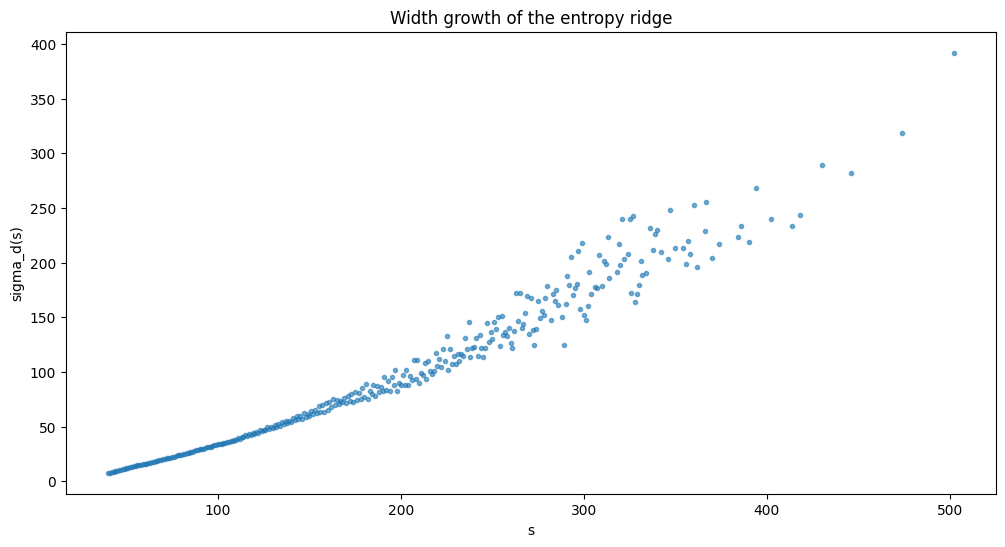

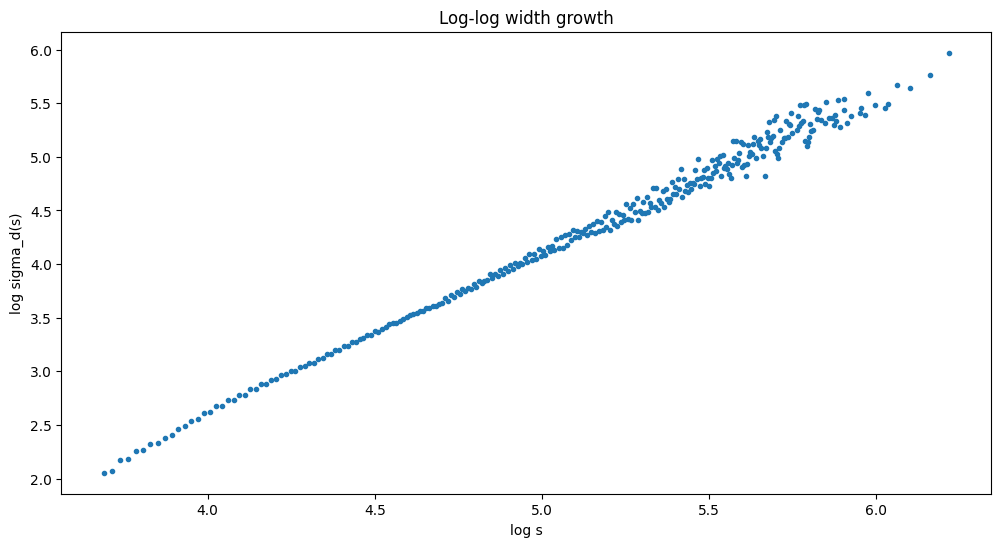

Power-law fit: sigma(s) ≈ 0.0344 * s^1.4941


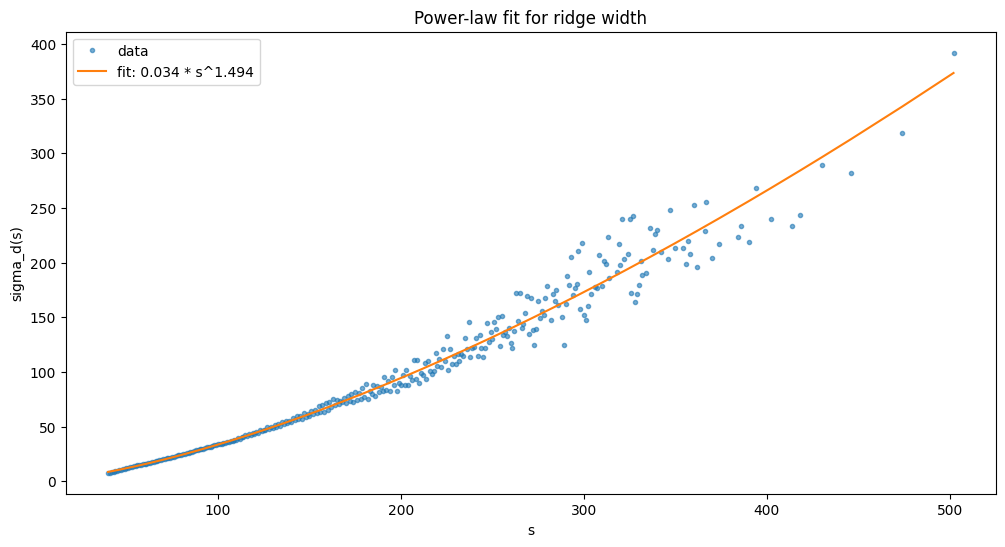

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# avoid tiny-s regime
df_fit = df_width[df_width["s"] >= 40].copy()

x = df_fit["s"].to_numpy(dtype=float)
y = df_fit["d_std"].to_numpy(dtype=float)

plt.figure(figsize=(12, 6))
plt.plot(x, y, ".", alpha=0.6)
plt.xlabel("s")
plt.ylabel("sigma_d(s)")
plt.title("Width growth of the entropy ridge")
plt.show()

# log-log
plt.figure(figsize=(12, 6))
plt.plot(np.log(x), np.log(y), ".")
plt.xlabel("log s")
plt.ylabel("log sigma_d(s)")
plt.title("Log-log width growth")
plt.show()

# fit power law: sigma ~ a * s^alpha
alpha, log_a = np.polyfit(np.log(x), np.log(y), 1)
a = np.exp(log_a)

print(f"Power-law fit: sigma(s) ≈ {a:.4f} * s^{alpha:.4f}")

# compare fit visually
y_fit = a * x**alpha

plt.figure(figsize=(12, 6))
plt.plot(x, y, ".", label="data", alpha=0.6)
plt.plot(x, y_fit, label=f"fit: {a:.3f} * s^{alpha:.3f}")
plt.xlabel("s")
plt.ylabel("sigma_d(s)")
plt.title("Power-law fit for ridge width")
plt.legend()
plt.show()

,s_min,n_points,a,alpha
0,40,315,0.034438,1.494103
1,60,295,0.036446,1.483619
2,80,275,0.036115,1.485287
3,100,255,0.035893,1.486403
4,120,235,0.036663,1.482604
5,150,205,0.037363,1.479235
6,200,155,0.040553,1.465010
7,250,105,0.087543,1.332331
8,300,57,0.175304,1.213988


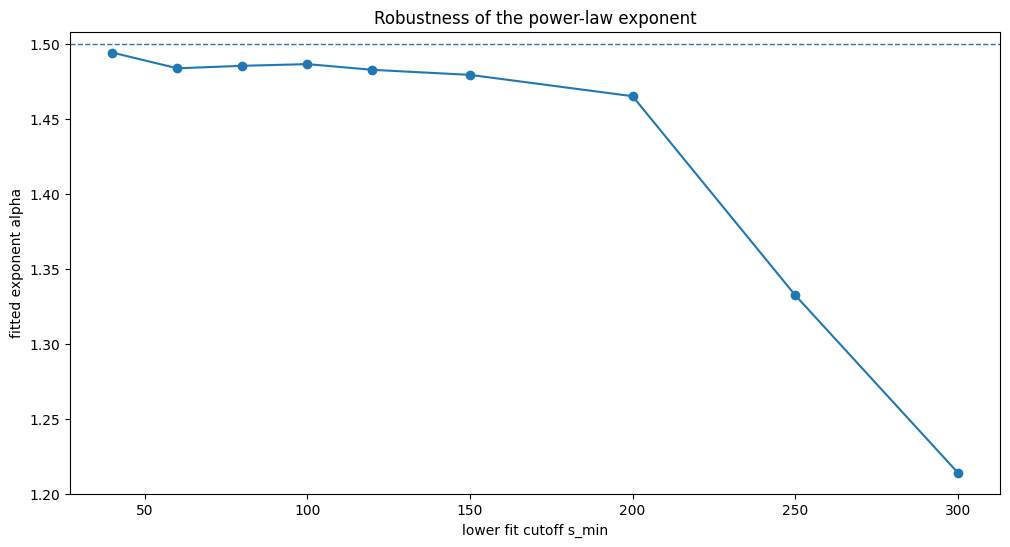

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Arbeitsbereich
df_fit = df_width[df_width["s"] >= 40].copy()

def fit_powerlaw(df_sub):
    x = df_sub["s"].to_numpy(dtype=float)
    y = df_sub["d_std"].to_numpy(dtype=float)
    alpha, log_a = np.polyfit(np.log(x), np.log(y), 1)
    a = np.exp(log_a)
    return a, alpha

# verschiedene Startschwellen testen
thresholds = [40, 60, 80, 100, 120, 150, 200, 250, 300]

rows = []
for smin in thresholds:
    sub = df_width[df_width["s"] >= smin].copy()
    if len(sub) < 20:
        continue
    a, alpha = fit_powerlaw(sub)
    rows.append((smin, len(sub), a, alpha))

df_alpha_scan = pd.DataFrame(rows, columns=["s_min", "n_points", "a", "alpha"])
display(df_alpha_scan)

plt.figure(figsize=(12, 6))
plt.plot(df_alpha_scan["s_min"], df_alpha_scan["alpha"], marker="o")
plt.axhline(1.5, linestyle="--", linewidth=1)
plt.xlabel("lower fit cutoff s_min")
plt.ylabel("fitted exponent alpha")
plt.title("Robustness of the power-law exponent")
plt.show()

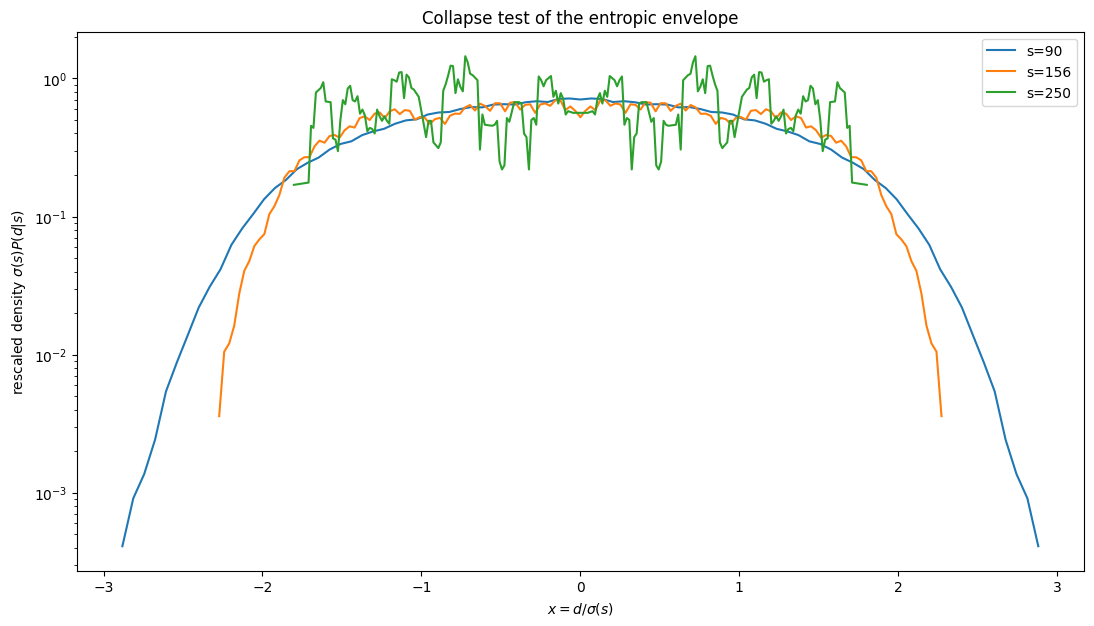

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

selected_s = [90, 156, 250, 400, 700, 1000]

plt.figure(figsize=(13, 7))

for s_val in selected_s:
    group = df_sd[df_sd["s"] == s_val].sort_values("d").copy()
    if len(group) == 0:
        continue

    d = group["d"].to_numpy(dtype=float)
    p = group["count"].to_numpy(dtype=float)
    p = p / p.sum()

    std = df_width.loc[df_width["s"] == s_val, "d_std"].values[0]
    x = d / std

    # Entropically rescaled density:
    # multiply by sigma so the area shape is more comparable
    y = p * std

    smooth_y = pd.Series(y).rolling(window=5, center=True, min_periods=1).mean().to_numpy()

    idx = np.argsort(x)
    plt.plot(x[idx], smooth_y[idx], label=f"s={s_val}")

plt.xlabel(r"$x=d/\sigma(s)$")
plt.ylabel(r"rescaled density $\sigma(s) P(d|s)$")
plt.title("Collapse test of the entropic envelope")
plt.yscale("log")
plt.legend()
plt.show()

,vertex_count,n_points,a,alpha
0,16,160,0.031844,1.491785
1,15,181,0.033087,1.491490
2,17,144,0.026961,1.520690
3,14,203,0.037463,1.471621
4,18,125,0.027929,1.502330
5,13,228,0.044627,1.440769


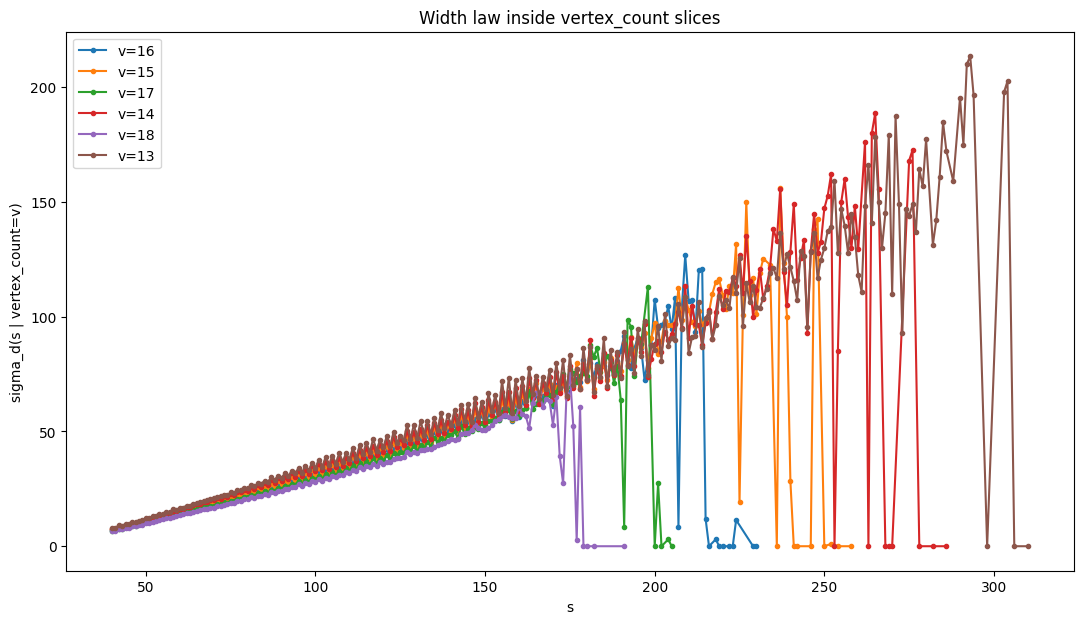

In [52]:
fit_rows = []

for v in top_v:
    sub = df_vwidth[(df_vwidth["vertex_count"] == v) & (df_vwidth["s"] >= 40)].copy()

    # entferne problematische Punkte
    sub = sub[(sub["d_std"] > 0) & np.isfinite(sub["d_std"])]

    if len(sub) < 10:
        continue

    x = sub["s"].to_numpy(dtype=float)
    y = sub["d_std"].to_numpy(dtype=float)

    # optional: nur Bereich nehmen, wo genug Daten sind
    # (verhindert Zittern am Rand)
    cutoff = np.percentile(x, 90)
    mask = x <= cutoff
    x = x[mask]
    y = y[mask]

    if len(x) < 5:
        continue

    alpha, log_a = np.polyfit(np.log(x), np.log(y), 1)
    a = np.exp(log_a)

    fit_rows.append((v, len(x), a, alpha))

df_vfits = pd.DataFrame(fit_rows, columns=["vertex_count", "n_points", "a", "alpha"])
display(df_vfits)

# =========================
# Plot sigma_v(s) for each selected v
# =========================
plt.figure(figsize=(13, 7))

for v in top_v:
    sub = df_vwidth[(df_vwidth["vertex_count"] == v) & (df_vwidth["s"] >= 40)]
    if len(sub) < 10:
        continue
    plt.plot(sub["s"], sub["d_std"], marker=".", linestyle="-", label=f"v={v}")

plt.xlabel("s")
plt.ylabel("sigma_d(s | vertex_count=v)")
plt.title("Width law inside vertex_count slices")
plt.legend()
plt.show()